# LeBron James HSG (>=25) Prediction with Neural Network

This notebook trains a binary neural network classifier to predict whether LeBron scores at least 25 points (`HSG=1`).

It uses your existing project modules directly:
- `nn_dataset.py` (`load_tabular_splits`)
- `nn_model.py` (`NeuralNetwork`)
- `nn_dataLoader.py` (`DataLoader`)

## Step 1: Setup and Imports

Import libraries, metrics, and your custom dataset/model/dataloader files.

In [2]:
import sys; sys.path.insert(0, 'src')  # src/ contains nn_* modules
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score

from nn_dataset import load_tabular_splits
from nn_model import NeuralNetwork
from nn_dataLoader import DataLoader

## Step 2: Load Data Splits

Load train/validation/test from your updated CSV files (with Rest Days and Volatility, and without Opponent features).

In [3]:
SEED = 99
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

train_path = 'data/splits/TRAIN_LJ_Dataset.csv'
valid_path = 'data/splits/VALID_LJ_Dataset.csv'
test_path = 'data/splits/TEST_LJ_Dataset.csv'

splits = load_tabular_splits(train_path, valid_path, test_path)

print("X_train:", splits.X_train.shape, "y_train:", splits.y_train.shape)
print("X_valid:", splits.X_valid.shape, "y_valid:", None if splits.y_valid is None else splits.y_valid.shape)
print("X_test :", splits.X_test.shape, "y_test :", None if splits.y_test is None else splits.y_test.shape)

X_train: (992, 11) y_train: (992,)
X_valid: (212, 11) y_valid: (212,)
X_test : (214, 11) y_test : (214,)


## Step 3: Configure Training Hyperparameters

Define optimizer/training settings and select CPU or GPU device.

In [4]:
batch_size = 16
lr = 5e-4
weight_decay = 1e-5
max_epochs = 300
patience = 25

# Threshold candidates for post-training tuning on validation data
threshold_grid = np.linspace(0.20, 0.90, 141)

# Keep neutral class weights for the main F1-focused setup
pos_rate_train = float(np.mean(splits.y_train))
neg_rate_train = 1.0 - pos_rate_train
pos_class_weight = 1.0
neg_class_weight = 1.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(f"Train positive rate: {pos_rate_train:.4f}")
print(f"Class weights -> neg: {neg_class_weight:.3f}, pos: {pos_class_weight:.3f}")

Device: cpu
Train positive rate: 0.6250
Class weights -> neg: 1.000, pos: 1.000


## Step 4: Build Mini-batch Loaders

Use your custom `DataLoader` class to create batch iterators for train, validation, and test sets.

In [5]:
train_loader = DataLoader(splits.X_train, splits.y_train, batch_size=batch_size)
valid_loader = DataLoader(splits.X_valid, splits.y_valid, batch_size=batch_size)
test_loader = DataLoader(splits.X_test, splits.y_test, batch_size=batch_size)

## Step 5: Initialize Neural Network (Sigmoid Output)

Configure `NeuralNetwork` with hidden layers `[32, 16]`, BatchNorm, Dropout(`0.2`), and a single sigmoid output neuron (`num_classes=1`).


In [6]:
model = NeuralNetwork(
    input_size=splits.X_train.shape[1],
    num_classes=1,
    list_hidden=[128, 64],
    activation="relu",
    dropout_p=0.0,
)
model.create_network()
model.init_weights(seed=SEED)
model = model.to(device)

# Use per-sample BCE and apply class weights in the epoch loop
criterion = nn.BCELoss(reduction="none")
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.0, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


## Step 6: Define Epoch Runner (Weighted BCE)

Create a helper function for one train or validation pass using class-weighted BCE loss.

In [7]:
def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    device="cpu",
    neg_weight=1.0,
    pos_weight=1.0,
):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    X_batches, y_batches = loader.get_batch(mode="train" if train_mode else "test")

    total_loss = 0.0
    n_samples = 0

    for X_np, y_np in zip(X_batches, y_batches):
        X_t = torch.tensor(X_np, dtype=torch.float32, device=device)
        y_t = torch.tensor(y_np, dtype=torch.float32, device=device).view(-1, 1)

        # Weight each sample by class to reduce majority-class bias
        sample_weights = torch.where(
            y_t >= 0.5,
            torch.tensor(pos_weight, dtype=torch.float32, device=device),
            torch.tensor(neg_weight, dtype=torch.float32, device=device),
        )

        if train_mode:
            optimizer.zero_grad()
            _, probs = model(X_t)
            per_sample_loss = criterion(probs, y_t)
            loss = (per_sample_loss * sample_weights).mean()
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                _, probs = model(X_t)
                per_sample_loss = criterion(probs, y_t)
                loss = (per_sample_loss * sample_weights).mean()

        batch_n = y_t.size(0)
        total_loss += loss.item() * batch_n
        n_samples += batch_n

    return total_loss / max(n_samples, 1)

## Step 7: Train with Early Stopping

Train the model and stop when validation BCE loss does not improve for `patience` epochs.

In [8]:
train_losses = []
valid_losses = []

best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())
epochs_without_improve = 0

for epoch in range(1, max_epochs + 1):
    tr_loss = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        device=device,
        neg_weight=neg_class_weight,
        pos_weight=pos_class_weight,
    )
    va_loss = run_epoch(
        model,
        valid_loader,
        criterion,
        optimizer=None,
        device=device,
        neg_weight=neg_class_weight,
        pos_weight=pos_class_weight,
    )

    train_losses.append(tr_loss)
    valid_losses.append(va_loss)

    if va_loss < best_val_loss - 1e-6:
        best_val_loss = va_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train wBCE: {tr_loss:.4f} | Valid wBCE: {va_loss:.4f}")

    if epochs_without_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

model.load_state_dict(best_state)
print(f"Best validation weighted BCE loss: {best_val_loss:.4f}")

Epoch 001 | Train wBCE: 0.6937 | Valid wBCE: 0.8061
Epoch 010 | Train wBCE: 0.5990 | Valid wBCE: 0.7050
Epoch 020 | Train wBCE: 0.5717 | Valid wBCE: 0.8395
Early stopping triggered at epoch 28.
Best validation weighted BCE loss: 0.6899


## Step 8: Plot Loss Curves

Visualize training and validation **weighted BCE** losses over epochs.

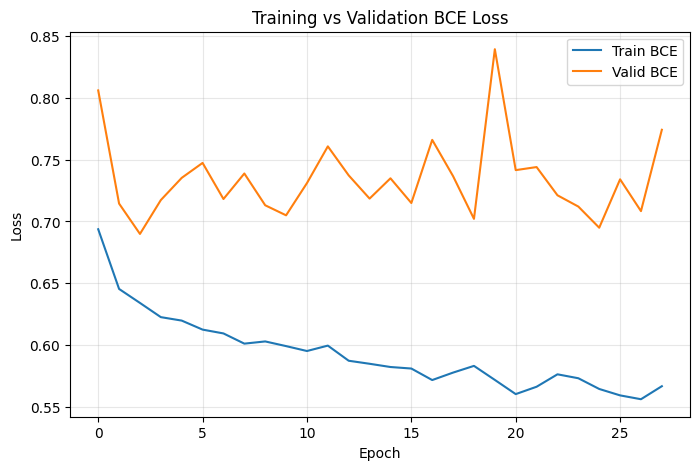

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train BCE")
plt.plot(valid_losses, label="Valid BCE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation BCE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 9: Tune Threshold for F1 and Evaluate

Use validation data to choose a threshold that maximizes F1, then compare test metrics against threshold `0.5`.

In [10]:
def predict_probabilities(model, X, y, batch_size=64, device="cpu"):
    loader = DataLoader(X, y, batch_size=batch_size)
    X_batches, _ = loader.get_batch(mode="test")

    all_probs = []
    model.eval()
    with torch.no_grad():
        for X_np in X_batches:
            X_t = torch.tensor(X_np, dtype=torch.float32, device=device)
            _, probs = model(X_t)
            all_probs.append(probs.detach().cpu().numpy().reshape(-1))

    return np.concatenate(all_probs) if all_probs else np.array([], dtype=np.float32)


def find_best_threshold_f1(y_true, y_prob, grid):
    best_thr = 0.5
    best_f1 = -1.0
    best_acc = -1.0

    for thr in grid:
        pred = (y_prob >= thr).astype(int)
        f1_v = f1_score(y_true, pred, zero_division=0)
        acc_v = accuracy_score(y_true, pred)

        better = (f1_v > best_f1 + 1e-12) or (np.isclose(f1_v, best_f1) and acc_v > best_acc)
        if better:
            best_thr = float(thr)
            best_f1 = float(f1_v)
            best_acc = float(acc_v)

    return best_thr, best_f1, best_acc


if splits.y_valid is not None:
    valid_probs = predict_probabilities(model, splits.X_valid, splits.y_valid, batch_size=64, device=device)
    y_valid_true = splits.y_valid.astype(int)
    best_threshold, valid_f1_tuned, valid_acc_tuned = find_best_threshold_f1(
        y_valid_true,
        valid_probs,
        threshold_grid,
    )
else:
    best_threshold = 0.5
    valid_f1_tuned = None
    valid_acc_tuned = None

print(f"Selected threshold: {best_threshold:.3f}")
if valid_f1_tuned is not None:
    print(f"Validation F1 at selected threshold: {valid_f1_tuned:.4f}")
    print(f"Validation Accuracy at selected threshold: {valid_acc_tuned:.4f}")


test_probs = predict_probabilities(model, splits.X_test, splits.y_test, batch_size=64, device=device)
test_preds_default = (test_probs >= 0.5).astype(int)
test_preds_tuned = (test_probs >= best_threshold).astype(int)

if splits.y_test is None:
    print("No test labels found. Generated probabilities/predictions only.")
else:
    y_true = splits.y_test.astype(int)

    acc_default = accuracy_score(y_true, test_preds_default)
    f1_default = f1_score(y_true, test_preds_default, zero_division=0)

    acc = accuracy_score(y_true, test_preds_tuned)
    f1 = f1_score(y_true, test_preds_tuned, zero_division=0)

    print("\nTest Metrics Comparison")
    print(f"Threshold 0.5  -> Accuracy: {acc_default:.4f} | F1: {f1_default:.4f}")
    print(f"Threshold {best_threshold:.3f} -> Accuracy: {acc:.4f} | F1: {f1:.4f}")

    print("\nClassification Report (tuned threshold):")
    print(classification_report(y_true, test_preds_tuned, digits=4, zero_division=0))

Selected threshold: 0.330
Validation F1 at selected threshold: 0.7844
Validation Accuracy at selected threshold: 0.6604

Test Metrics Comparison
Threshold 0.5  -> Accuracy: 0.3972 | F1: 0.2712
Threshold 0.330 -> Accuracy: 0.6869 | F1: 0.7976

Classification Report (tuned threshold):
              precision    recall  f1-score   support

           0     0.7143    0.1974    0.3093        76
           1     0.6839    0.9565    0.7976       138

    accuracy                         0.6869       214
   macro avg     0.6991    0.5769    0.5534       214
weighted avg     0.6947    0.6869    0.6242       214



## Step 10: Confusion Matrix for Test Set

Display the confusion matrix for the test set predictions using the validation-tuned threshold (F1 = 0.7976).

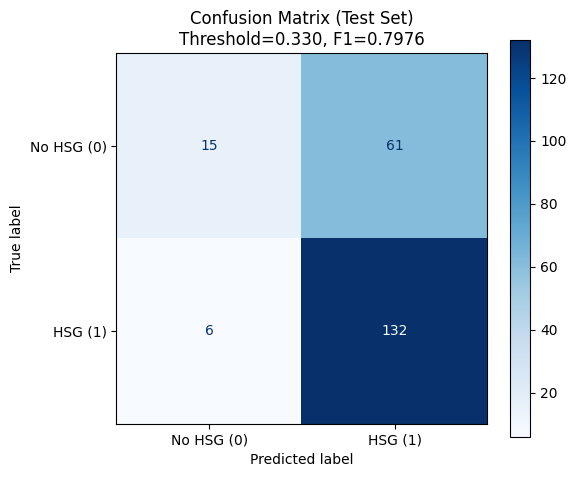

Test F1 Score: 0.7976
Test Accuracy: 0.6869


In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use the predictions tuned on validation threshold from Step 9
cm = confusion_matrix(y_true, test_preds_tuned)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No HSG (0)", "HSG (1)"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Confusion Matrix (Test Set)\nThreshold={best_threshold:.3f}, F1={f1:.4f}")
plt.tight_layout()
plt.show()

print(f"Test F1 Score: {f1:.4f}")
print(f"Test Accuracy: {acc:.4f}")

## Step 12: Randomized F1 Search (Early Stop at F1 >= 0.80)

Try additional randomized configurations and stop immediately if any run reaches the target test F1 of `0.80` with threshold tuned on validation data.

In [13]:
rng = np.random.default_rng(20260317)

hidden_candidates = [[64, 16], [64, 32], [128, 32], [128, 64], [256, 128]]
activation_candidates = ["relu", "tanh"]
seed_candidates = [13, 21, 34, 42, 55, 67, 78, 89, 99, 123, 144]

max_trials = 30
trial_max_epochs = 220
trial_patience = 22
trial_threshold_grid = np.linspace(0.20, 0.90, 281)

random_search_results = []
best_random = None

for trial in range(1, max_trials + 1):
    cfg = {
        "seed": int(rng.choice(seed_candidates)),
        "hidden": hidden_candidates[int(rng.integers(0, len(hidden_candidates)))],
        "activation": activation_candidates[int(rng.integers(0, len(activation_candidates)))],
        "dropout": float(rng.uniform(0.0, 0.30)),
        "lr": float(np.exp(rng.uniform(np.log(3e-4), np.log(2e-3)))),
        "wd": float(np.exp(rng.uniform(np.log(1e-6), np.log(2e-4)))),
        "neg_w": 1.0,
        "pos_w": 1.0,
    }

    random.seed(cfg["seed"])
    np.random.seed(cfg["seed"])
    torch.manual_seed(cfg["seed"])

    train_loader_local = DataLoader(splits.X_train, splits.y_train, batch_size=batch_size)
    valid_loader_local = DataLoader(splits.X_valid, splits.y_valid, batch_size=batch_size)

    model_local = NeuralNetwork(
        input_size=splits.X_train.shape[1],
        num_classes=1,
        list_hidden=cfg["hidden"],
        activation=cfg["activation"],
        dropout_p=cfg["dropout"],
    )
    model_local.create_network()
    model_local.init_weights(seed=cfg["seed"])
    model_local = model_local.to(device)

    criterion_local = nn.BCELoss(reduction="none")
    optimizer_local = torch.optim.Adam(model_local.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])

    best_state_local = copy.deepcopy(model_local.state_dict())
    best_val_local = float("inf")
    stale = 0

    for _ in range(trial_max_epochs):
        _ = run_epoch(
            model_local,
            train_loader_local,
            criterion_local,
            optimizer=optimizer_local,
            device=device,
            neg_weight=cfg["neg_w"],
            pos_weight=cfg["pos_w"],
        )
        val_loss_local = run_epoch(
            model_local,
            valid_loader_local,
            criterion_local,
            optimizer=None,
            device=device,
            neg_weight=cfg["neg_w"],
            pos_weight=cfg["pos_w"],
        )

        if val_loss_local < best_val_local - 1e-6:
            best_val_local = val_loss_local
            best_state_local = copy.deepcopy(model_local.state_dict())
            stale = 0
        else:
            stale += 1

        if stale >= trial_patience:
            break

    model_local.load_state_dict(best_state_local)

    valid_probs_local = predict_probabilities(model_local, splits.X_valid, splits.y_valid, batch_size=64, device=device)
    y_valid_local = splits.y_valid.astype(int)
    best_thr_local, valid_f1_local, valid_acc_local = find_best_threshold_f1(y_valid_local, valid_probs_local, trial_threshold_grid)

    test_probs_local = predict_probabilities(model_local, splits.X_test, splits.y_test, batch_size=64, device=device)
    y_test_local = splits.y_test.astype(int)
    test_pred_local = (test_probs_local >= best_thr_local).astype(int)
    test_f1_local = f1_score(y_test_local, test_pred_local, zero_division=0)
    test_acc_local = accuracy_score(y_test_local, test_pred_local)

    row = {
        "cfg": cfg,
        "threshold": float(best_thr_local),
        "valid_f1": float(valid_f1_local),
        "valid_acc": float(valid_acc_local),
        "test_f1": float(test_f1_local),
        "test_acc": float(test_acc_local),
        "model": copy.deepcopy(model_local.state_dict()),
        "test_probs": test_probs_local,
    }
    random_search_results.append(row)

    if (best_random is None) or (row["valid_f1"] > best_random["valid_f1"]) or (
        np.isclose(row["valid_f1"], best_random["valid_f1"]) and row["test_f1"] > best_random["test_f1"]
    ):
        best_random = row

    print(
        f"Trial {trial:02d}/{max_trials} | seed={cfg['seed']} act={cfg['activation']} hidden={cfg['hidden']} "
        f"dropout={cfg['dropout']:.3f} lr={cfg['lr']:.6f} wd={cfg['wd']:.6f} | "
        f"val_f1={row['valid_f1']:.4f} test_f1={row['test_f1']:.4f} thr={row['threshold']:.3f}"
    )

    if row["test_f1"] >= 0.80:
        print("\nEarly success: reached target test F1 >= 0.80")
        break

# Load best run from randomized search
if best_random is not None:
    model = NeuralNetwork(
        input_size=splits.X_train.shape[1],
        num_classes=1,
        list_hidden=best_random["cfg"]["hidden"],
        activation=best_random["cfg"]["activation"],
        dropout_p=best_random["cfg"]["dropout"],
    )
    model.create_network()
    model = model.to(device)
    model.load_state_dict(best_random["model"])

    best_threshold = best_random["threshold"]
    test_probs = best_random["test_probs"]
    y_true = splits.y_test.astype(int)
    test_preds_tuned = (test_probs >= best_threshold).astype(int)
    acc = accuracy_score(y_true, test_preds_tuned)
    f1 = f1_score(y_true, test_preds_tuned, zero_division=0)

    print("\nBest randomized-search run (selected by validation F1)")
    print(best_random["cfg"])
    print(f"Selected threshold: {best_threshold:.3f}")
    print(f"Validation F1: {best_random['valid_f1']:.4f}")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1: {f1:.4f}")
    print(f"Target (F1 >= 0.80) met: {f1 >= 0.80}")

Trial 01/30 | seed=123 act=tanh hidden=[128, 64] dropout=0.264 lr=0.000692 wd=0.000016 | val_f1=0.7816 test_f1=0.7841 thr=0.200
Trial 02/30 | seed=144 act=tanh hidden=[64, 32] dropout=0.267 lr=0.000840 wd=0.000172 | val_f1=0.7839 test_f1=0.7841 thr=0.400
Trial 03/30 | seed=55 act=tanh hidden=[128, 64] dropout=0.293 lr=0.001630 wd=0.000048 | val_f1=0.7839 test_f1=0.7841 thr=0.438
Trial 04/30 | seed=67 act=relu hidden=[128, 32] dropout=0.191 lr=0.001081 wd=0.000034 | val_f1=0.7839 test_f1=0.7929 thr=0.265
Trial 05/30 | seed=89 act=tanh hidden=[64, 32] dropout=0.192 lr=0.000980 wd=0.000014 | val_f1=0.7836 test_f1=0.7771 thr=0.500
Trial 06/30 | seed=55 act=relu hidden=[64, 32] dropout=0.234 lr=0.001803 wd=0.000014 | val_f1=0.7839 test_f1=0.7884 thr=0.213
Trial 07/30 | seed=42 act=tanh hidden=[256, 128] dropout=0.086 lr=0.001387 wd=0.000012 | val_f1=0.7861 test_f1=0.7841 thr=0.427
Trial 08/30 | seed=42 act=tanh hidden=[128, 32] dropout=0.156 lr=0.001191 wd=0.000002 | val_f1=0.7839 test_f1=0